<a href="https://colab.research.google.com/github/eilselx/MACHINE-LEARNING-PROJECT---LIFE-EXPECTANCY-ESTIMATOR-/blob/main/MACHINE_LEARNING_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Project: Life Expectancy Prediction

# Predicting Life Expectancy Using National Health Indicators

### Statistics and Machine Learning Project

**Institution:** SRH University – MSc Digital Health and Data Science

**Course:** Statistics and Machine Learning

**Semester:** Summer Semester 2026

# Project Overview

Life expectancy is one of the most important indicators of a country's overall health and development. It is influenced by healthcare access, disease burden, economic conditions, environmental factors, and public health interventions.

This project develops a machine learning model to predict life expectancy using national health indicators from the WHO Health Indicators dataset. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model development, evaluation, and interpretation.

# Project Objectives

The objectives of this project are to:

- Predict life expectancy using national health indicators.
- Perform data preprocessing and exploratory data analysis.
- Engineer meaningful features for model development.
- Compare multiple regression algorithms.
- Select the best-performing model using MAE, RMSE and R².
- Interpret the final model using feature importance and residual analysis.

# Import Required Libraries

This section imports the libraries required for data manipulation, visualization, machine learning, and model evaluation throughout the project.

In [ ]:
from google.colab import files
import zipfile
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Accessing the Project Repository

The project files are stored in a GitHub repository. This section clones the repository into the Colab environment and prepares the dataset for analysis.

In [ ]:
!git clone https://github.com/eilselx/MACHINE-LEARNING-PROJECT---LIFE-EXPECTANCY-ESTIMATOR-.git

Cloning into 'MACHINE-LEARNING-PROJECT---LIFE-EXPECTANCY-ESTIMATOR-'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 64 (delta 20), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 2.32 MiB | 5.61 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [ ]:
%cd MACHINE-LEARNING-PROJECT---LIFE-EXPECTANCY-ESTIMATOR-

/content/MACHINE-LEARNING-PROJECT---LIFE-EXPECTANCY-ESTIMATOR-


In [ ]:
%cd data

/content/MACHINE-LEARNING-PROJECT---LIFE-EXPECTANCY-ESTIMATOR-/data


In [ ]:

# Define the zip file and extraction directory
zip_file = Path("archive(1).zip")
extract_dir = Path(".")

# Extract the dataset only if it hasn't been extracted already
if not (extract_dir / "health_indicators.csv").exists():
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted. Skipping extraction.")

Dataset extracted successfully.


# 1. Data Loading

The WHO Health Indicators dataset is loaded into a pandas DataFrame. This dataset contains demographic, healthcare, socioeconomic, environmental, and disease-related indicators that will be used to predict life expectancy.

In [ ]:
#Load the dataset
df = pd.read_csv("health_indicators.csv")

In [ ]:
df.head()

,country_code,country_name,region,income_level,year,population,population_growth,urban_pct,life_expectancy,life_expectancy_male,...,stunting_pct,wasting_pct,overweight_children_pct,undernourishment_pct,fertility_rate,adolescent_fertility,prenatal_care_pct,gdp_per_capita,gdp_per_capita_ppp,poverty_rate
0,ABW,Aruba,Latin America & Caribbean,High income,2000,90588.0,1.030817,65.354550,72.939,70.149,...,NaN,NaN,NaN,NaN,1.845,43.729,NaN,20681.023027,30245.706974,NaN
1,ABW,Aruba,Latin America & Caribbean,High income,2001,91439.0,0.935033,65.335114,73.044,70.251,...,NaN,NaN,NaN,NaN,1.813,40.463,NaN,20740.132583,31920.239073,NaN
2,ABW,Aruba,Latin America & Caribbean,High income,2002,92074.0,0.692052,65.282069,73.135,70.364,...,NaN,NaN,NaN,NaN,1.800,38.185,NaN,21307.248251,31888.508737,NaN
3,ABW,Aruba,Latin America & Caribbean,High income,2003,93128.0,1.138229,65.198292,73.236,70.488,...,NaN,NaN,NaN,NaN,1.808,37.807,NaN,21949.485996,32507.084315,NaN
4,ABW,Aruba,Latin America & Caribbean,High income,2004,95138.0,2.135358,65.088653,73.223,70.487,...,NaN,NaN,NaN,NaN,1.819,38.761,NaN,23700.631990,35059.273098,NaN


In [ ]:
df.shape

(5275, 48)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5275 entries, 0 to 5274
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country_code                   5275 non-null   object 
 1   country_name                   5275 non-null   object 
 2   region                         5275 non-null   object 
 3   income_level                   5275 non-null   object 
 4   year                           5275 non-null   int64  
 5   population                     5275 non-null   float64
 6   population_growth              5274 non-null   float64
 7   urban_pct                      5275 non-null   float64
 8   life_expectancy                5275 non-null   float64
 9   life_expectancy_male           5275 non-null   float64
 10  life_expectancy_female         5275 non-null   float64
 11  death_rate                     5275 non-null   float64
 12  birth_rate                     5275 non-null   f

In [ ]:
display(df.describe())


,year,population,population_growth,urban_pct,life_expectancy,life_expectancy_male,life_expectancy_female,death_rate,birth_rate,health_expenditure_pct_gdp,...,stunting_pct,wasting_pct,overweight_children_pct,undernourishment_pct,fertility_rate,adolescent_fertility,prenatal_care_pct,gdp_per_capita,gdp_per_capita_ppp,poverty_rate
count,5275.000000,5.275000e+03,5274.000000,5275.000000,5275.000000,5275.000000,5275.000000,5275.000000,5275.000000,4514.000000,...,844.000000,843.000000,806.000000,3762.000000,5275.000000,5275.000000,741.000000,5110.000000,4838.000000,1827.000000
mean,2012.000000,3.378305e+07,1.280475,58.716732,70.748244,68.215760,73.394403,8.192702,21.095707,6.222646,...,24.009360,5.896679,6.198015,10.937400,2.797145,51.097317,86.791826,15749.091058,19781.847712,9.492118
std,7.211786,1.323408e+08,1.618914,23.674753,8.701547,8.471691,9.066795,3.412191,10.888048,2.867900,...,15.043393,4.401812,4.499476,11.043652,1.468998,42.893201,16.137098,25074.200336,22391.204701,17.142033
min,2000.000000,9.544000e+03,-11.356645,8.043814,14.665000,12.383000,20.006000,0.841000,4.200000,1.222602,...,0.500000,0.100000,0.000000,2.500000,0.721000,0.505000,16.100000,109.593814,403.983197,0.000000
25%,2006.000000,7.743870e+05,0.297465,39.060949,65.356000,62.722000,67.976000,6.033500,11.746000,4.126287,...,10.800000,2.400000,2.725000,2.500000,1.670000,15.427500,82.500000,1544.567936,3899.860735,0.300000
50%,2012.000000,5.943366e+06,1.175030,60.031069,72.442000,69.217000,75.689000,7.607000,18.172000,5.640688,...,23.800000,4.900000,5.300000,6.300000,2.274000,39.131000,92.800000,5356.365656,11309.514697,1.500000
75%,2018.000000,2.201484e+07,2.210221,77.627285,77.197000,74.500000,80.115000,9.780500,28.806500,7.966407,...,35.325000,8.700000,8.700000,15.600000,3.638500,75.234000,97.600000,20032.321089,28679.803239,9.800000
max,2024.000000,1.450936e+09,21.700343,100.000000,86.497000,84.560000,88.626000,72.483000,53.390000,27.089685,...,64.000000,24.600000,29.600000,72.500000,7.829000,206.357000,100.000000,288001.433369,180939.439450,94.900000


## 2. Data Preprocessing

Before building machine learning models, the dataset must be cleaned to ensure data quality. This section examines missing values, removes features with excessive missing data, imputes remaining missing values, checks for duplicate records, and prepares the final cleaned dataset for analysis.

In [ ]:
# Calculate the percentage of missing values for each feature
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

,0
obesity_pct,100.000000
diabetes_pct,92.037915
prenatal_care_pct,85.952607
overweight_children_pct,84.720379
wasting_pct,84.018957
stunting_pct,84.000000
noncommunicable_death_pct,79.184834
communicable_death_pct,79.184834
smoking_female,75.279621
smoking_male,75.279621


In [ ]:
# Create a copy of the original dataset for preprocessing
df_clean = df.copy()

### Feature Removal

Features with a large proportion of missing values were removed because imputing a substantial amount of missing data could introduce bias and reduce model reliability.

In [ ]:
# Remove features with excessive missing values (>50%)
columns_to_drop = [
    "obesity_pct",
    "diabetes_pct",
    "prenatal_care_pct",
    "overweight_children_pct",
    "wasting_pct",
    "stunting_pct"
]

# Drop the columns
df_clean.drop(columns=columns_to_drop, inplace=True)

# Check the new shape
df_clean.shape

(5275, 42)

## Missing Value Imputation

Missing values were imputed using a hierarchical strategy to preserve country-specific trends whenever possible before falling back to global statistics.

In [ ]:
def hierarchical_imputation(df, columns):
    """
    Hierarchically imputes missing values.

    Strategy:
    1. Forward fill within each country.
    2. Backward fill within each country.
    3. Fill any remaining missing values using the regional median.
    4. Fill any remaining missing values using the global median.

    This approach preserves country-specific temporal patterns while ensuring that no missing values remain.
    """

    for col in columns:

        # Step 1: Country-level fill
        df[col] = (
            df.groupby("country_name")[col]
            .transform(lambda x: x.ffill().bfill())
        )

        # Step 2: Regional median
        df[col] = df[col].fillna(
            df.groupby("region")[col].transform("median")
        )

        # Step 3: Global median
        df[col] = df[col].fillna(
            df[col].median()
        )

    return df

In [ ]:
# Impute healthcare infrastructure indicators
healthcare_cols = [
    "physicians_per_1000",
    "hospital_beds_per_1000",
    "nurses_per_1000"
]

df_clean = hierarchical_imputation(df_clean, healthcare_cols)

In [ ]:
# Impute water and sanitation indicators
water_cols = [
    "safe_water_pct",
    "sanitation_pct"
]

df_clean = hierarchical_imputation(df_clean, water_cols)

In [ ]:
# Impute disease burden indicators
disease_cols = [
    "hiv_incidence",
    "maternal_mortality",
    "communicable_death_pct",
    "noncommunicable_death_pct"
]

df_clean = hierarchical_imputation(df_clean, disease_cols)

In [ ]:
# Impute lifestyle indicators
lifestyle_cols = [
    "smoking_male",
    "smoking_female",
    "alcohol_per_capita"
]

df_clean = hierarchical_imputation(df_clean, lifestyle_cols)

In [ ]:
# Impute economic indicators
economic_cols = [
    "health_expenditure_pct_gdp",
    "health_expenditure_per_capita",
    "gdp_per_capita",
    "gdp_per_capita_ppp",
    "poverty_rate"
]

df_clean = hierarchical_imputation(df_clean, economic_cols)

### Remaining Missing Values

After hierarchical imputation, the dataset is inspected again to identify any remaining missing values requiring additional treatment.

In [ ]:
df_clean.isnull().sum().sort_values(ascending=False)

,0
handwashing_pct,3494
immunization_hib3,1542
undernourishment_pct,1513
immunization_bcg,1393
immunization_measles,520
immunization_pol3,520
immunization_dpt,520
neonatal_mortality,425
under5_mortality,425
tb_incidence,218


In [ ]:
# Remove the remaining feature with substantial missing values
df_clean.drop(columns=["handwashing_pct"], inplace=True)

In [ ]:
remaining_cols = [
    "population_growth",
    "tb_incidence",
    "under5_mortality",
    "neonatal_mortality",
    "immunization_measles",
    "immunization_dpt",
    "immunization_pol3",
    "immunization_bcg",
    "immunization_hib3",
    "undernourishment_pct"
]

df_clean = hierarchical_imputation(df_clean, remaining_cols)

In [ ]:
# Verify that all missing values have been handled
df_clean.isnull().sum().sort_values(ascending=False)

,0
country_code,0
country_name,0
region,0
income_level,0
year,0
population,0
population_growth,0
urban_pct,0
life_expectancy,0
life_expectancy_male,0


### Duplicate Check

Duplicate records are checked to ensure that each observation is unique and does not introduce bias into the analysis.

In [ ]:
# Number of duplicate rows
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
# Display the final structure of the cleaned dataset
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5275 entries, 0 to 5274
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country_code                   5275 non-null   object 
 1   country_name                   5275 non-null   object 
 2   region                         5275 non-null   object 
 3   income_level                   5275 non-null   object 
 4   year                           5275 non-null   int64  
 5   population                     5275 non-null   float64
 6   population_growth              5275 non-null   float64
 7   urban_pct                      5275 non-null   float64
 8   life_expectancy                5275 non-null   float64
 9   life_expectancy_male           5275 non-null   float64
 10  life_expectancy_female         5275 non-null   float64
 11  death_rate                     5275 non-null   float64
 12  birth_rate                     5275 non-null   f

In [ ]:
import os

# Create the processed folder if it doesn't exist
os.makedirs("data/processed", exist_ok=True)

# Save the cleaned dataset
df_clean.to_csv(
    "data/processed/WHO_Health_Indicators_Clean.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


#3. Exploratory Data Analysis (EDA)

Contributor: Lavanya

After preprocessing, the cleaned dataset is explored to better understand its characteristics before model development. Exploratory Data Analysis (EDA) helps identify data distributions, detect outliers, examine relationships between variables, and uncover patterns that may influence life expectancy prediction.

The analyses performed in this section include:

- Summary statistics
- Outlier analysis
- Feature distribution analysis
- Correlation analysis

In [ ]:
# Display descriptive statistics for all numerical variables
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5275.0,2.012000e+03,7.211786e+00,2000.000000,2006.000000,2.012000e+03,2.018000e+03,2.024000e+03
population,5275.0,3.378305e+07,1.323408e+08,9544.000000,774387.000000,5.943366e+06,2.201484e+07,1.450936e+09
population_growth,5275.0,1.280385e+00,1.618774e+00,-11.356645,0.297478,1.174698e+00,2.209400e+00,2.170034e+01
urban_pct,5275.0,5.871673e+01,2.367475e+01,8.043814,39.060949,6.003107e+01,7.762728e+01,1.000000e+02
life_expectancy,5275.0,7.074824e+01,8.701547e+00,14.665000,65.356000,7.244200e+01,7.719700e+01,8.649700e+01
life_expectancy_male,5275.0,6.821576e+01,8.471691e+00,12.383000,62.722000,6.921700e+01,7.450000e+01,8.456000e+01
life_expectancy_female,5275.0,7.339440e+01,9.066795e+00,20.006000,67.976000,7.568900e+01,8.011500e+01,8.862600e+01
death_rate,5275.0,8.192702e+00,3.412191e+00,0.841000,6.033500,7.607000e+00,9.780500e+00,7.248300e+01
birth_rate,5275.0,2.109571e+01,1.088805e+01,4.200000,11.746000,1.817200e+01,2.880650e+01,5.339000e+01
health_expenditure_pct_gdp,5275.0,6.267306e+00,2.937163e+00,1.222602,4.270919,5.806386e+00,7.799432e+00,2.708969e+01


## Summary Statistics

The descriptive statistics provide an overview of the numerical variables in the cleaned dataset.

**Key observations:**

- The dataset contains substantial variation across countries and years.
- Economic indicators such as **GDP per capita**, **health expenditure**, and **population** exhibit large ranges and strong right-skewed distributions.
- Mortality-related variables show considerable variability, reflecting differences in healthcare quality and socioeconomic development across countries.
- Life expectancy values are concentrated within a narrower range compared to many predictor variables, making it a suitable target for regression modelling.

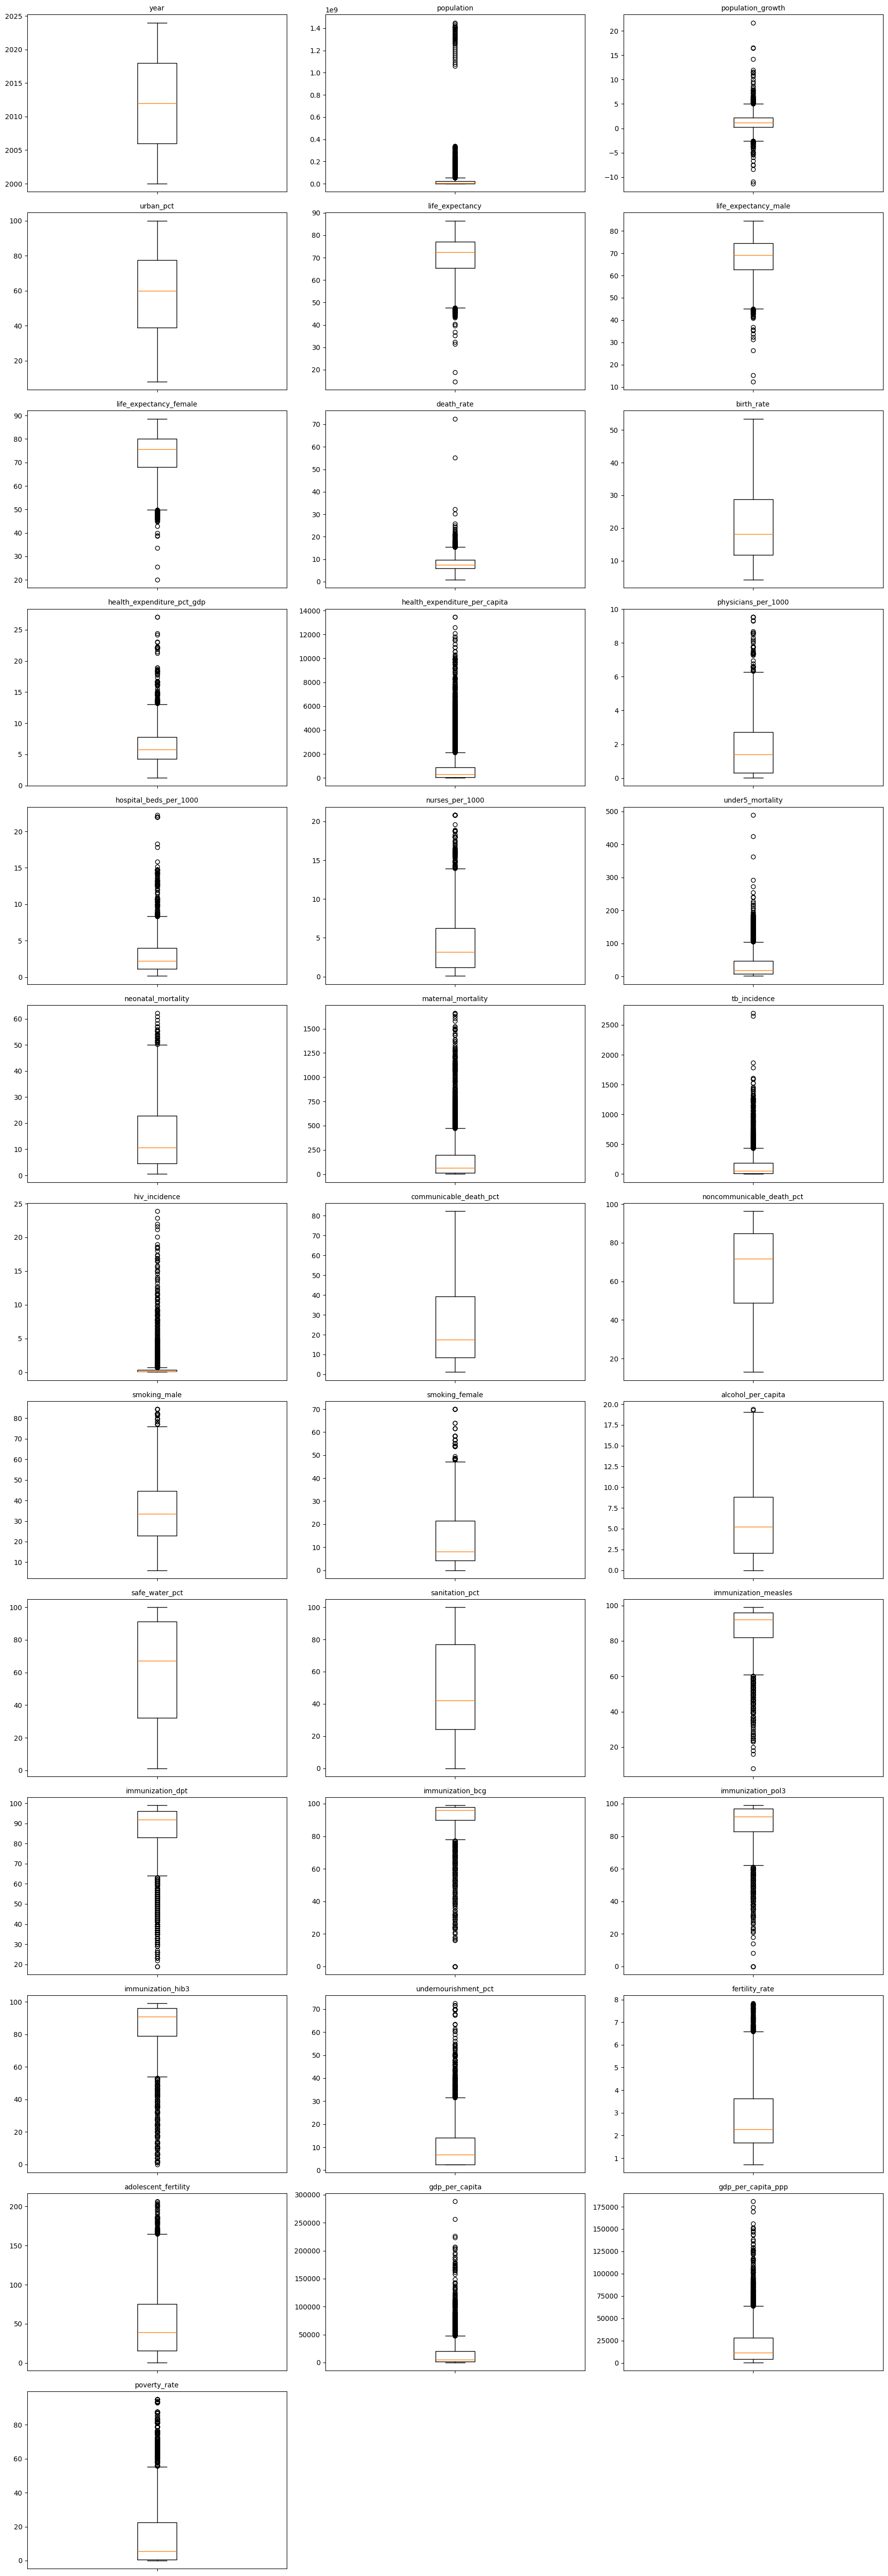

In [ ]:
# Visualize potential outliers using boxplots
numeric_columns = df_clean.select_dtypes(include=['float64', 'int64']).columns
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    axes[i].boxplot(df_clean[col], vert=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', labelbottom=False)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


## Outlier Analysis

Boxplots were used to identify potential outliers within the numerical features.

**Key observations:**

- Economic indicators such as **GDP per capita** and **health expenditure per capita** contain several high-value outliers, reflecting highly developed countries.
- Mortality indicators, including **maternal mortality** and **under-five mortality**, also exhibit extreme values corresponding to countries with poorer health outcomes.
- Variables such as **year** and **urban population percentage** show relatively stable distributions with few or no significant outliers.
- The identified outliers represent genuine differences between countries rather than data entry errors; therefore, they were retained in the dataset.

Number of numerical features: 37


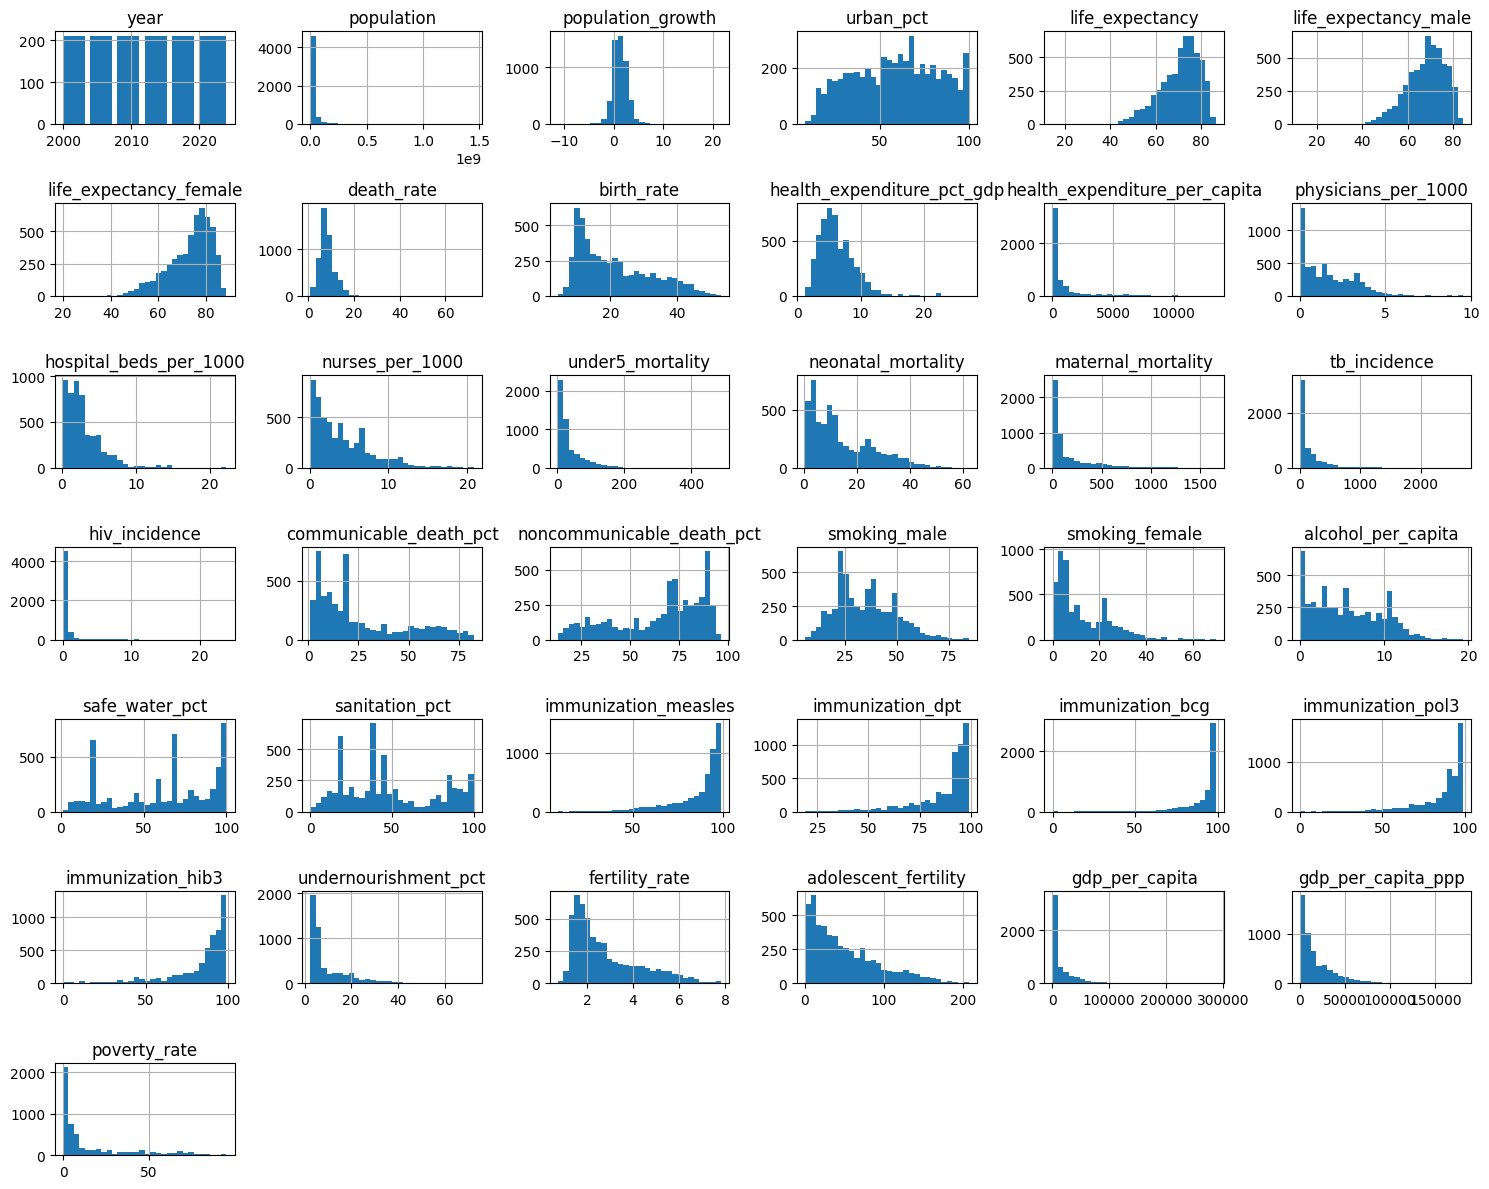

In [ ]:
# Visualize the distribution of numerical features
numerical_columns = df_clean.select_dtypes(include=['float64', 'int64']).columns
print("Number of numerical features:", len(numerical_columns))
df_clean[numerical_columns].hist(
    figsize=(15, 12),
    bins=30
)
plt.tight_layout()
plt.show()

## Feature Distribution Analysis

Histograms were generated to examine the distribution of each numerical feature.

**Key observations:**

- Economic variables such as **GDP per capita**, **population**, and **health expenditure** are strongly right-skewed.
- Several healthcare indicators, including immunization rates and life expectancy, are concentrated toward higher values, resulting in left-skewed distributions.
- Mortality-related variables display long right tails due to a relatively small number of countries experiencing extremely poor health outcomes.
- The observed skewness motivated the application of log transformations to selected variables during feature engineering.

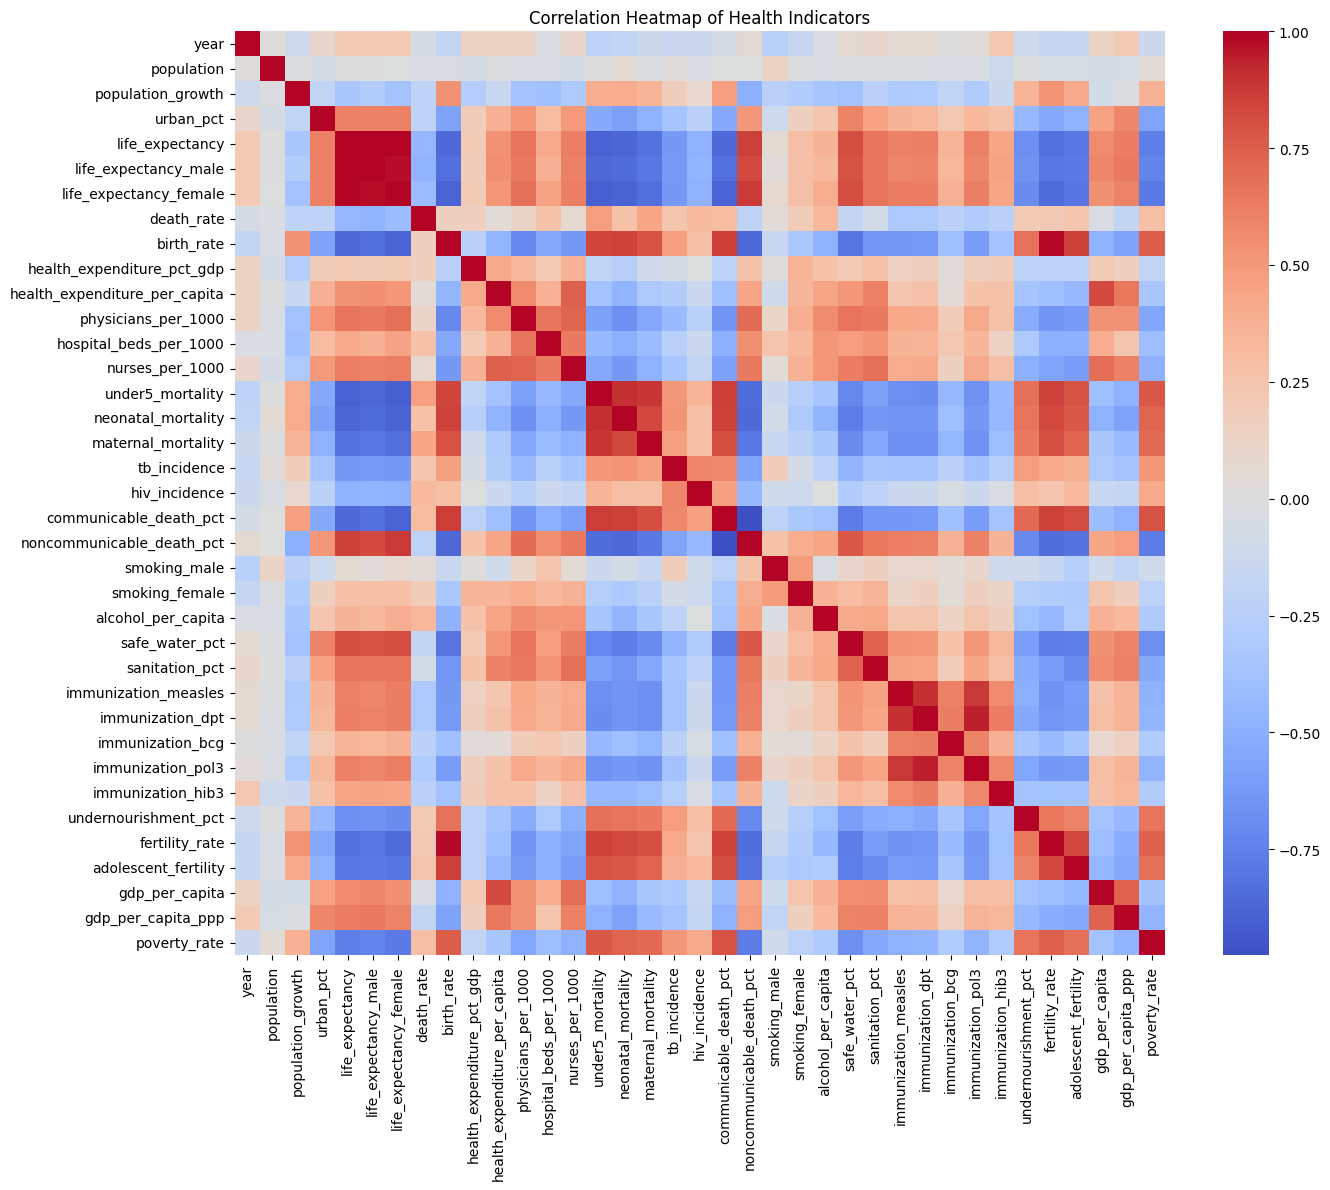

In [ ]:
# Compute and visualize the correlation matrix
correlation_matrix = df_clean[numerical_columns].corr()
correlation_matrix.head()
plt.figure(figsize=(15,12))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Health Indicators")
plt.show()

## Correlation Analysis

A correlation heatmap was used to examine the relationships between numerical variables.

**Key observations:**

- **Life expectancy** is positively correlated with indicators such as **safe water access**, **sanitation coverage**, **GDP per capita**, and **healthcare resources**.
- Strong negative correlations exist between life expectancy and mortality-related variables, including **under-five mortality**, **maternal mortality**, and **communicable disease deaths**.
- Several mortality and fertility indicators are highly correlated with one another, suggesting the presence of multicollinearity.
- These relationships provide valuable insight into the factors influencing life expectancy and informed subsequent feature engineering decisions.

#4. Feature Engineering

Contributor : Advait

Following the insights gained from Exploratory Data Analysis (EDA), feature engineering is performed to improve the predictive capability of the dataset. This process involves selecting relevant features, creating new domain-specific variables, reducing redundancy, and transforming skewed features to better prepare the data for machine learning models.

The following feature engineering steps are performed:

- Feature Selection
- Creation of Healthcare workforce density
- Creation of the Disease Burden Ratio
- Creation of the Overall Immunization Index
- Log Transformation of Skewed Features
- Construction of the Final Feature Engineering Pipeline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#Modelling dataset and Leakage removal

# Define target variable and columns to remove due to target leakage
target_col = 'life_expectancy'
leakage_columns = ['life_expectancy_male', 'life_expectancy_female']

# Create the modelling dataframe from our clean dataset
df_model = df_clean.copy()

# Drop leakage columns if they exist in the dataframe
dropped_cols = [col for col in leakage_columns if col in df_model.columns]
df_model = df_model.drop(columns=dropped_cols)

print(f"Modelling dataset successfully created.")
print(f"   - Shape: {df_model.shape}")
print(f"   - Target variable: '{target_col}'")
print(f"   - Removed leakage columns: {dropped_cols}")

Modelling dataset successfully created.
   - Shape: (5275, 39)
   - Target variable: 'life_expectancy'
   - Removed leakage columns: ['life_expectancy_male', 'life_expectancy_female']


In [ ]:
# Separate features (X) and target (y)
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Using an 80-20 split with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Modelling dataset created and split successfully!")
print(f"   Training set shape: {X_train.shape}")
print(f"   Testing set shape:  {X_test.shape}")

Modelling dataset created and split successfully!
   Training set shape: (4220, 38)
   Testing set shape:  (1055, 38)


## Feature 1 – Healthcare Workforce Density

The first engineered feature combined the number of physicians and nurses per 1,000 population into a single variable called **Healthcare Workforce Density**.

This feature was evaluated to determine whether combining the two healthcare workforce indicators would improve the predictive performance of the models.

In [ ]:
# Create the Healthcare Workforce Density feature
def add_healthcare_workforce_density(df):
    """
    Creates 'healthcare_workforce_density' by summing physicians and nurses per 1,000 people.
    Returns a copy of the dataframe to keep transformations modular.
    """
    df_out = df.copy()
    df_out['healthcare_workforce_density'] = (
        df_out['physicians_per_1000'] + df_out['nurses_per_1000']
    )
    return df_out

# Apply transformation to train and test sets separately
X_train_fe = add_healthcare_workforce_density(X_train)
X_test_fe  = add_healthcare_workforce_density(X_test)

print("Feature #1 ('healthcare_workforce_density') added to X_train and X_test.")
print(f"   - X_train shape: {X_train_fe.shape}")
print(f"   - X_test shape:  {X_test_fe.shape}")

Feature #1 ('healthcare_workforce_density') added to X_train and X_test.
   - X_train shape: (4220, 39)
   - X_test shape:  (1055, 39)


### Evaluating the feature 1


In [ ]:

# 0. Select Numeric Features Only

# Filter out text/string columns (like country codes) for model fitting
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num  = X_test.select_dtypes(include=['number'])

X_train_fe1_num = X_train_fe.select_dtypes(include=['number'])
X_test_fe1_num  = X_test_fe.select_dtypes(include=['number'])

print(f"Fitting model using {X_train_num.shape[1]} numeric features.")


# 1. Baseline Model (Without Feature #1)

baseline_model = RandomForestRegressor(random_state=42)
baseline_model.fit(X_train_num, y_train)

y_pred_base = baseline_model.predict(X_test_num)

mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = mean_squared_error(y_test, y_pred_base) ** 0.5
r2_base = r2_score(y_test, y_pred_base)


# 2. Engineered Model (With Feature #1)

fe1_model = RandomForestRegressor(random_state=42)
fe1_model.fit(X_train_fe1_num, y_train)

y_pred_fe1 = fe1_model.predict(X_test_fe1_num)

mae_fe1 = mean_absolute_error(y_test, y_pred_fe1)
rmse_fe1 = mean_squared_error(y_test, y_pred_fe1) ** 0.5
r2_fe1 = r2_score(y_test, y_pred_fe1)


# 3. Comparison Summary Table

evaluation_df = pd.DataFrame({
    'Metric': ['MAE (Years)', 'RMSE (Years)', 'R² Score'],
    'Baseline (Without Feature #1)': [mae_base, rmse_base, r2_base],
    'With Feature #1': [mae_fe1, rmse_fe1, r2_fe1],
    'Difference (Engineered - Base)': [mae_fe1 - mae_base, rmse_fe1 - rmse_base, r2_fe1 - r2_base]
})

print("\nFEATURE #1 EVALUATION REPORT")
print(evaluation_df.to_string(index=False))

Fitting model using 34 numeric features.

FEATURE #1 EVALUATION REPORT
      Metric  Baseline (Without Feature #1)  With Feature #1  Difference (Engineered - Base)
 MAE (Years)                       0.431151         0.435952                        0.004800
RMSE (Years)                       0.727552         0.730343                        0.002791
    R² Score                       0.993134         0.993081                       -0.000053


### Evaluation of Feature #1

The Healthcare Workforce Density feature was tested against the baseline model to determine whether it improved predictive performance.

The feature was **not included** in the final modelling pipeline for the following reasons:

* **Worsened Performance:** Testing it against our baseline model actually increased error (MAE rose by ~0.0048 years) and reduced overall accuracy ($R^2$).
* **Redundant for Tree Models:** Tree-based models like Random Forests can already split on doctors and nurses independently. Adding a simple sum created noise without giving the model any new or helpful signals.


### Feature Engineering 2: Disease Burden Ratio

To better represent a country's health profile, a new feature called **Disease Burden Ratio** was created. This feature compares communicable disease deaths with non-communicable disease deaths, providing a single indicator of the relative disease burden.

In [ ]:
# Step 2: Create Disease Burden Ratio
# Create a ratio between communicable and non-communicable disease deaths

def add_disease_burden_ratio(df):
    """
    Creates 'disease_burden_ratio' by dividing communicable death percentage
    by noncommunicable death percentage plus a constant to avoid division by zero.
    """
    df_out = df.copy()
    df_out['disease_burden_ratio'] = (
        df_out['communicable_death_pct'] / (df_out['noncommunicable_death_pct'] + 1e-5)
    )
    return df_out

# Create dataset versions with Feature #2
X_train_fe2 = add_disease_burden_ratio(X_train)
X_test_fe2  = add_disease_burden_ratio(X_test)



Evaluating the Feature 2

In [ ]:
# Select numeric features for model fitting
X_train_fe2_num = X_train_fe2.select_dtypes(include=['number'])
X_test_fe2_num  = X_test_fe2.select_dtypes(include=['number'])



# 1. Baseline Model (Without Feature #2)

baseline_model = RandomForestRegressor(random_state=42)
baseline_model.fit(X_train_num, y_train)

y_pred_base = baseline_model.predict(X_test_num)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = mean_squared_error(y_test, y_pred_base) ** 0.5
r2_base   = r2_score(y_test, y_pred_base)


# 2. Model with Feature #2 Included

fe2_model = RandomForestRegressor(random_state=42)
fe2_model.fit(X_train_fe2_num, y_train)

y_pred_fe2 = fe2_model.predict(X_test_fe2_num)

mae_fe2  = mean_absolute_error(y_test, y_pred_fe2)
rmse_fe2 = mean_squared_error(y_test, y_pred_fe2) ** 0.5
r2_fe2   = r2_score(y_test, y_pred_fe2)


# 3. Comparison Summary Table

evaluation_df2 = pd.DataFrame({
    'Metric': ['MAE (Years)', 'RMSE (Years)', 'R² Score'],
    'Baseline (Without Feature #2)': [mae_base, rmse_base, r2_base],
    'With Feature #2': [mae_fe2, rmse_fe2, r2_fe2],
    'Difference (Engineered - Base)': [mae_fe2 - mae_base, rmse_fe2 - rmse_base, r2_fe2 - r2_base]
})

print("FEATURE #2 EVALUATION REPORT")
print(evaluation_df2.to_string(index=False))

FEATURE #2 EVALUATION REPORT
      Metric  Baseline (Without Feature #2)  With Feature #2  Difference (Engineered - Base)
 MAE (Years)                       0.431151         0.431180                        0.000029
RMSE (Years)                       0.727552         0.726610                       -0.000943
    R² Score                       0.993134         0.993152                        0.000018


Interpreting the Results:

- RMSE Improved: Decreased by ~0.00094 years (the model made fewer large errors).
- $R^2$ Improved: Increased by +0.000018 (explaining slightly more variance).
- MAE Negligible Shift: Increased by 0.000029 years—which equals roughly 15 minutes of life expectancy!

### Feature Engineering 3: Overall Immunization Index

**Goal:** Eliminate multicollinearity and reduce feature space redundancy.

**Why:** The 5 individual vaccine columns all measure the same core concept (public healthcare coverage). Averaging them into a single composite score reduces our feature count (34 → 30 columns) and eliminates collinear noise without losing predictive power.

In [ ]:
# Step 3: Create Overall Immunization Index
def add_immunization_index(df, drop_individual=True):
    """
    Creates 'overall_immunization_index' by taking the mean across the 5 vaccine coverage columns.
    If drop_individual=True, removes the original 5 vaccine columns to reduce collinearity.
    """
    df_out = df.copy()
    vaccine_cols = [
        'immunization_measles',
        'immunization_dpt',
        'immunization_bcg',
        'immunization_pol3',
        'immunization_hib3'
    ]

# Calculate the average immunization coverage across all vaccines
    df_out['overall_immunization_index'] = df_out[vaccine_cols].mean(axis=1)

# Remove the original vaccination variables after aggregation
    if drop_individual:
        df_out = df_out.drop(columns=vaccine_cols)

    return df_out

Evaluation of Feature 3


In [ ]:
# Create dataset versions with the composite index (dropping original 5 vaccine columns)
X_train_imm = add_immunization_index(X_train, drop_individual=True)
X_test_imm  = add_immunization_index(X_test, drop_individual=True)

# Select numeric columns for fitting
X_train_imm_num = X_train_imm.select_dtypes(include=['number'])
X_test_imm_num  = X_test_imm.select_dtypes(include=['number'])

# Train & Evaluate Model with Aggregated Feature

imm_model = RandomForestRegressor(random_state=42)
imm_model.fit(X_train_imm_num, y_train)

y_pred_imm = imm_model.predict(X_test_imm_num)

mae_imm  = mean_absolute_error(y_test, y_pred_imm)
rmse_imm = mean_squared_error(y_test, y_pred_imm) ** 0.5
r2_imm   = r2_score(y_test, y_pred_imm)


# Comparison Summary Table

evaluation_imm_df = pd.DataFrame({
    'Metric': ['MAE (Years)', 'RMSE (Years)', 'R² Score'],
    'Baseline (5 Individual Vaccines)': [mae_base, rmse_base, r2_base],
    'Aggregated (1 Combined Index)': [mae_imm, rmse_imm, r2_imm],
    'Difference (Aggregated - Base)': [mae_imm - mae_base, rmse_imm - rmse_base, r2_imm - r2_base]
})

print("=== IMMUNIZATION AGGREGATION EVALUATION REPORT ===")
print(f"Features reduced from {X_train_num.shape[1]} to {X_train_imm_num.shape[1]}")
print(evaluation_imm_df.to_string(index=False))

=== IMMUNIZATION AGGREGATION EVALUATION REPORT ===
Features reduced from 34 to 30
      Metric  Baseline (5 Individual Vaccines)  Aggregated (1 Combined Index)  Difference (Aggregated - Base)
 MAE (Years)                          0.431151                       0.428953                       -0.002198
RMSE (Years)                          0.727552                       0.725856                       -0.001697
    R² Score                          0.993134                       0.993166                        0.000032


We eliminated 4 redundant columns (reducing total numeric features from 34 down to 30), and all three evaluation metrics improved:

*   MAE dropped by ~0.0022 years (higher accuracy).

*   RMSE dropped by ~0.0017 years (fewer large errors).
*   $R^2$ increased by +0.000032.





## Transform Skewed Features

Exploratory Data Analysis revealed that several numerical variables have highly right-skewed distributions. A logarithmic transformation (`log1p`) is applied to these features to reduce skewness, stabilize variance, and improve model learning.

In [ ]:
#LOG TRANSFORMATIONS

def apply_log_transformations(df, columns_to_transform):
    """
    Applies log1p (log(1 + x)) transformation to specified skewed numeric columns.
    Returns a copy of the dataframe with transformed columns.
    """
    df_out = df.copy()
    for col in columns_to_transform:
        if col in df_out.columns:
            # Create a log-transformed version or replace in-place
            df_out[col] = np.log1p(df_out[col])
    return df_out

# List of highly right-skewed features
skewed_columns = [
    'gdp_per_capita',
    'gdp_per_capita_ppp',
    'health_expenditure_per_capita',
    'population',
    'tb_incidence',
    'poverty_rate'
]

# Apply the log1p transformation
X_train_log = apply_log_transformations(X_train_imm, skewed_columns)
X_test_log  = apply_log_transformations(X_test_imm, skewed_columns)

Evaluation of Log transfomed data

In [ ]:
# Select numeric features for fitting
X_train_log_num = X_train_log.select_dtypes(include=['number'])
X_test_log_num  = X_test_log.select_dtypes(include=['number'])


# Train & Evaluate Model on Log-Transformed Data

log_model = RandomForestRegressor(random_state=42)
log_model.fit(X_train_log_num, y_train)

y_pred_log = log_model.predict(X_test_log_num)

mae_log  = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
r2_log   = r2_score(y_test, y_pred_log)


# Comparison Summary Table

evaluation_log_df = pd.DataFrame({
    'Metric': ['MAE (Years)', 'RMSE (Years)', 'R² Score'],
    'Pre-Log (Aggregated Index)': [mae_imm, rmse_imm, r2_imm],
    'Post-Log Transformed': [mae_log, rmse_log, r2_log],
    'Difference (Log - Pre-Log)': [mae_log - mae_imm, rmse_log - rmse_imm, r2_log - r2_imm]
})

print("LOG TRANSFORMATION EVALUATION REPORT")
print(evaluation_log_df.to_string(index=False))

LOG TRANSFORMATION EVALUATION REPORT
      Metric  Pre-Log (Aggregated Index)  Post-Log Transformed  Difference (Log - Pre-Log)
 MAE (Years)                    0.428953              0.428176                   -0.000777
RMSE (Years)                    0.725856              0.725372                   -0.000483
    R² Score                    0.993166              0.993175                    0.000009


In [ ]:
# Compare skewness scores before and after log transformation
skew_before = X_train_imm[skewed_columns].skew()
skew_after  = X_train_log[skewed_columns].skew()

skew_comparison = pd.DataFrame({
    'Feature': skewed_columns,
    'Skewness (Before Log)': skew_before.values,
    'Skewness (After Log)': skew_after.values
})

print("=== SKEWNESS REDUCTION REPORT ===")
print(skew_comparison.to_string(index=False))

=== SKEWNESS REDUCTION REPORT ===
                      Feature  Skewness (Before Log)  Skewness (After Log)
               gdp_per_capita               3.362606             -0.027287
           gdp_per_capita_ppp               2.109978             -0.205929
health_expenditure_per_capita               2.940633              0.129928
                   population               8.793414             -0.422647
                 tb_incidence               3.404806             -0.188471
                 poverty_rate               1.558155              0.195930


### Log Transformation Evaluation Takeaways

The log transformation report confirms that our dataset is **clean, mathematically stable, and fully prepped for multi-model benchmarking**.

* **Tree Invariance in Action:** Random Forest splits features on relative rank ordering rather than feature scale. Compressing right-skewed tails barely changed tree performance (MAE improved slightly by < 0.0008 years).
* **Pipeline Integrity Verified:** The stable metrics prove our $\log(1 + x)$ transformation executed safely without producing `NaN` or infinite (`inf`) values.
* **Essential Preparation for Non-Tree Models:** While tree-based models ignore feature scale, converting these heavily skewed distributions into bell curves is critical for linear models (Ridge/Lasso), distance-based models (KNN/SVR), and neural networks.

### Statistical Verification of Log Transformations

A skewness value between **-0.5 and +0.5** indicates a symmetric, normal-like (bell-shaped) distribution.

* **Pre-Transformation:** Features exhibited severe right-skewness (ranging from +1.56 up to +8.79), caused by long tails of extreme high values.
* **Post-Transformation:** All transformed features landed squarely within the **[-0.5, +0.5] range**, proving statistically that the extreme tails were compressed into symmetric distributions ready for linear and distance-based algorithms.

#Combining the features in one dataset for modeling

In [ ]:
def prepare_final_features(df, skewed_cols=None):
    """
    Applies all accepted feature engineering steps in sequence:
    1. Adds Disease Burden Ratio (Feature #2)
    2. Aggregates the 5 vaccine columns into a single index & drops originals
    3. Applies log1p transformation to right-skewed columns
    """
    df_out = df.copy()


    # 1. Feature #2: Disease Burden Ratio

    if 'communicable_death_pct' in df_out.columns and 'noncommunicable_death_pct' in df_out.columns:
        df_out['disease_burden_ratio'] = (
            df_out['communicable_death_pct'] / (df_out['noncommunicable_death_pct'] + 1e-5)
        )


    # 2. Aggregation: Overall Immunization Index

    vaccine_cols = [
        'immunization_measles',
        'immunization_dpt',
        'immunization_bcg',
        'immunization_pol3',
        'immunization_hib3'
    ]

    # Check if all vaccine columns exist before aggregating
    if all(col in df_out.columns for col in vaccine_cols):
        df_out['overall_immunization_index'] = df_out[vaccine_cols].mean(axis=1)
        df_out = df_out.drop(columns=vaccine_cols)


    # 3. Log Transformations

    if skewed_cols:
        for col in skewed_cols:
            if col in df_out.columns:
                df_out[col] = np.log1p(df_out[col])

    return df_out

# List of target right-skewed features
skewed_columns = [
    'gdp_per_capita',
    'gdp_per_capita_ppp',
    'health_expenditure_per_capita',
    'population',
    'tb_incidence',
    'poverty_rate'
]

# Apply pipeline to train and test sets
X_train_final = prepare_final_features(X_train, skewed_cols=skewed_columns)
X_test_final  = prepare_final_features(X_test, skewed_cols=skewed_columns)

### Pipeline Consolidation

We consolidated all validated feature transformations into a single, reusable function (`prepare_final_features`).

**What the pipeline does:**
1. **Adds Domain Interactions:** Creates the `disease_burden_ratio`.
2. **Reduces Redundancy:** Replaces 5 vaccine features with a single `overall_immunization_index`.
3. **Normalizes Distributions:** Applies $\log(1 + x)$ transformations to heavily right-skewed predictors.

Pipeline

In [ ]:
# Keep only numeric features for model training
X_train_final_num = X_train_final.select_dtypes(include=["number"])
X_test_final_num = X_test_final.select_dtypes(include=["number"])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final_num)
X_test_scaled = scaler.transform(X_test_final_num)

#5. Model Development

Contributor: Leslie

After completing data preprocessing, exploratory data analysis, and feature engineering, the final engineered dataset is used to train and evaluate multiple machine learning regression models.

The objective of this section is to compare different regression algorithms and identify the model that best predicts life expectancy.

The following models are evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

All models are evaluated using the same training and testing datasets based on:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

## Model 1 – Linear Regression

Linear Regression is used as the baseline regression model. It assumes a linear relationship between the predictor variables and the target variable (life expectancy). The model provides a benchmark against which more complex machine learning algorithms can be compared.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [ ]:
# Create the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# Generate predictions on the testing dataset
y_pred_lr= lr_model.predict(X_test_scaled)

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

In [ ]:
print(f"Linear Regression")
print(f"MAE : {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²  : {r2_lr:.3f}")

Linear Regression
MAE : 1.374
RMSE: 1.802
R²  : 0.958


## Model 2 – Decision Tree Regressor

Decision Tree Regression is a non-linear machine learning algorithm that predicts life expectancy by recursively splitting the dataset based on feature values. It can capture complex relationships without requiring feature scaling.

In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)
# Train the model
dt_model.fit(X_train_final_num, y_train)


DecisionTreeRegressor(random_state=42)

In [ ]:
# Predict on the test set
y_pred_dt = dt_model.predict(X_test_final_num)

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

In [ ]:
print("Decision Tree Regressor")
print(f"MAE : {mae_dt:.3f}")
print(f"RMSE: {rmse_dt:.3f}")
print(f"R²  : {r2_dt:.3f}")

Decision Tree Regressor
MAE : 0.633
RMSE: 1.065
R²  : 0.985


## Model 3 – Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used for structured tabular datasets.

In [ ]:
# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Train the model
rf_model.fit(X_train_final_num, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict on the test set
y_pred_rf = rf_model.predict(X_test_final_num)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

In [ ]:
print("Random Forest Regressor")
print(f"MAE : {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²  : {r2_rf:.3f}")

Random Forest Regressor
MAE : 0.428
RMSE: 0.732
R²  : 0.993


## Model 4 – Gradient Boosting Regressor

Gradient Boosting builds an ensemble of decision trees sequentially, where each new tree learns from the prediction errors of the previous trees. This often leads to improved predictive performance compared to a single decision tree.

In [ ]:
# Create the Gradient Boosting model
gb_model = GradientBoostingRegressor(
    random_state=42
)

In [ ]:
# Train the model
gb_model.fit(X_train_final_num, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
# Predict on the test set
y_pred_gb = gb_model.predict(X_test_final_num)

In [ ]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

r2_gb = r2_score(y_test, y_pred_gb)

In [ ]:
print("Gradient Boosting Regressor")
print(f"MAE : {mae_gb:.3f}")
print(f"RMSE: {rmse_gb:.3f}")
print(f"R²  : {r2_gb:.3f}")

Gradient Boosting Regressor
MAE : 0.844
RMSE: 1.121
R²  : 0.984


## Model 5 – XGBoost Regressor

Extreme Gradient Boosting (XGBoost) is an optimized implementation of gradient boosting that incorporates regularization, efficient tree construction, and parallel computation. Due to its strong predictive performance on structured datasets, it is included as the final regression model for comparison.

In [ ]:
# Create the XGBoost model
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

In [ ]:
objective="reg:squarederror"

In [ ]:
# Train the model
xgb_model.fit(X_train_final_num, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test_final_num)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

r2_xgb = r2_score(y_test, y_pred_xgb)

In [ ]:
print("XGBoost Regressor")
print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")

XGBoost Regressor
MAE : 0.423
RMSE: 0.701
R²  : 0.994


##6. Model Comparison - Results

The performance of all regression models is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

The best-performing model is selected based on the lowest prediction errors (MAE and RMSE) together with the highest R² score.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb,
        rmse_xgb
    ],
    "R²": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_xgb
    ]
})

results = results.sort_values(by="R²", ascending=False).reset_index(drop=True)

results

,Model,MAE,RMSE,R²
0,XGBoost,0.423064,0.701287,0.993621
1,Random Forest,0.427705,0.731922,0.993051
2,Decision Tree,0.633103,1.065284,0.985280
3,Gradient Boosting,0.843703,1.120968,0.983701
4,Linear Regression,1.374472,1.801800,0.957889


## Best Model Selection

To identify the most suitable model for predicting life expectancy, five regression algorithms were trained and evaluated using the same training and testing datasets. The models were compared based on three evaluation metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

Among the evaluated models, **Extreme Gradient Boosting (XGBoost)** achieved the best overall performance. It produced the **highest R² score (0.9936)**, indicating that it explained approximately **99.36% of the variance** in life expectancy. Additionally, it achieved the **lowest MAE (0.4230)** and **lowest RMSE (0.7012)**, demonstrating the highest prediction accuracy and the smallest prediction errors.

Based on these results, **XGBoost was selected as the final model** for further interpretation and analysis. The subsequent sections focus on understanding the model's behavior by examining feature importance and interpreting the factors that most strongly influence life expectancy predictions.

## Target Leakage Investigation

The initial model results showed exceptionally high predictive performance, suggesting that some predictor variables might contain information directly related to the target variable.

To verify this, a target leakage assessment was performed by examining the correlations between the target variable and the predictor variables.

### Correlation Analysis

After removing the suspected leakage variables, the correlation between the remaining numerical features and the target variable (**life_expectancy**) was examined.

This analysis was performed to verify that no remaining predictor exhibited an unrealistically high correlation that might indicate residual target leakage.

In [ ]:
# Compute the correlation matrix for the modelling dataset
corr = df_model.corr(numeric_only=True)

# Display the correlation of each feature with the target variable
corr["life_expectancy"].sort_values(ascending=False)

,life_expectancy
life_expectancy,1.000000
noncommunicable_death_pct,0.854305
safe_water_pct,0.808023
physicians_per_1000,0.667799
sanitation_pct,0.661884
gdp_per_capita_ppp,0.625212
nurses_per_1000,0.617560
immunization_dpt,0.616612
immunization_measles,0.612008
urban_pct,0.609220


### Findings

The correlation analysis indicates that no remaining predictor has a near-perfect correlation with **life_expectancy**.

The strongest positive correlations are observed for:

- **Non-communicable death percentage** (0.854)
- **Safe water access** (0.808)
- **Physicians per 1,000 people** (0.668)
- **Sanitation coverage** (0.662)

The strongest negative correlations include:

- **Under-five mortality** (-0.892)
- **Neonatal mortality** (-0.872)
- **Birth rate** (-0.861)
- **Communicable death percentage** (-0.861)

These relationships are expected from a public health perspective and do not suggest target leakage. Therefore, the remaining predictors were considered appropriate for model development.

# Model Interpretation

After selecting XGBoost as the best-performing model, the model was interpreted to understand which features contributed most to its predictions.

Feature importance provides insight into the relative contribution of each predictor to the model's decision-making process. Higher importance values indicate features that have a greater influence on predicting life expectancy.

## Feature Importance Analysis

The importance score of each feature was extracted from the trained XGBoost model and ranked in descending order. This analysis helps identify the most influential health, demographic, and socioeconomic indicators affecting life expectancy predictions.

In [ ]:
# Extract feature importance scores from the trained XGBoost model
feature_importance = pd.DataFrame({
    "Feature": X_train_final_num.columns,
    "Importance": xgb_model.feature_importances_
})

# Rank features from most to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the ranked feature importance
feature_importance.head(15)

,Feature,Importance
11,under5_mortality,0.510764
13,maternal_mortality,0.210500
26,gdp_per_capita,0.113632
4,death_rate,0.061873
22,sanitation_pct,0.019423
25,adolescent_fertility,0.009983
29,disease_burden_ratio,0.009980
7,health_expenditure_per_capita,0.008336
17,noncommunicable_death_pct,0.007340
5,birth_rate,0.006615


### Interpretation

The feature importance analysis shows that the XGBoost model relies primarily on mortality-related indicators when predicting life expectancy.

**Key observations:**

- **Under-five mortality** is the most influential predictor, accounting for approximately **51%** of the model's total importance. This indicates that child mortality is the strongest indicator of overall life expectancy in the dataset.
- **Maternal mortality** is the second most important feature, highlighting the strong relationship between maternal health and national life expectancy.
- **GDP per capita** ranks third, suggesting that a country's economic development plays a significant role in health outcomes.
- Additional contributors include **death rate**, **sanitation coverage**, **adolescent fertility**, and the engineered **Disease Burden Ratio**, although their influence is considerably smaller.
- The inclusion of the **Disease Burden Ratio** among the important predictors suggests that the engineered feature provides useful information beyond the original variables.

Overall, the feature importance rankings are consistent with established public health knowledge, indicating that mortality, economic development, and healthcare infrastructure are major determinants of life expectancy.

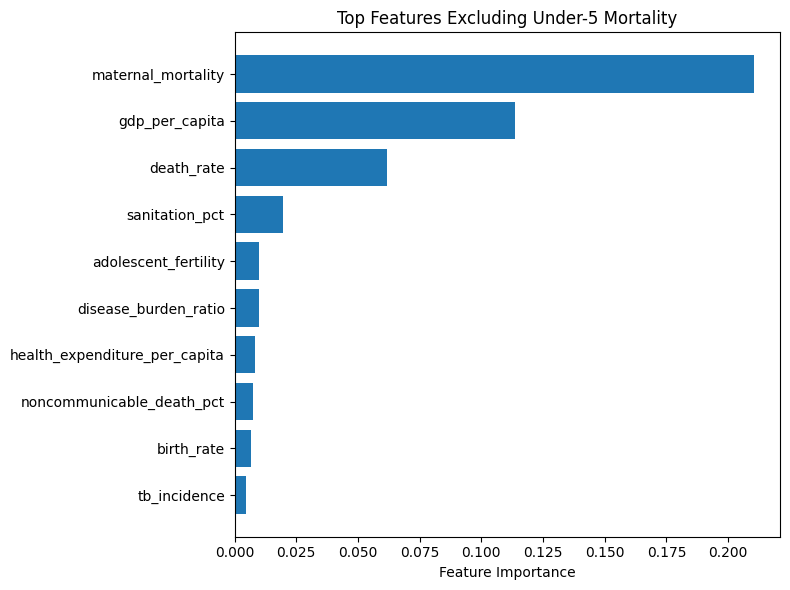

In [ ]:
top_features = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .iloc[1:11]   # Skip under5_mortality
    .sort_values("Importance")
)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top Features Excluding Under-5 Mortality")
plt.tight_layout()
plt.show()

## Prediction vs Actual Values

To assess the predictive performance of the selected XGBoost model, the predicted life expectancy values are compared with the actual values from the testing dataset.

If the model performs well, the predicted values should closely follow the diagonal reference line, indicating that the predictions closely match the true observations.

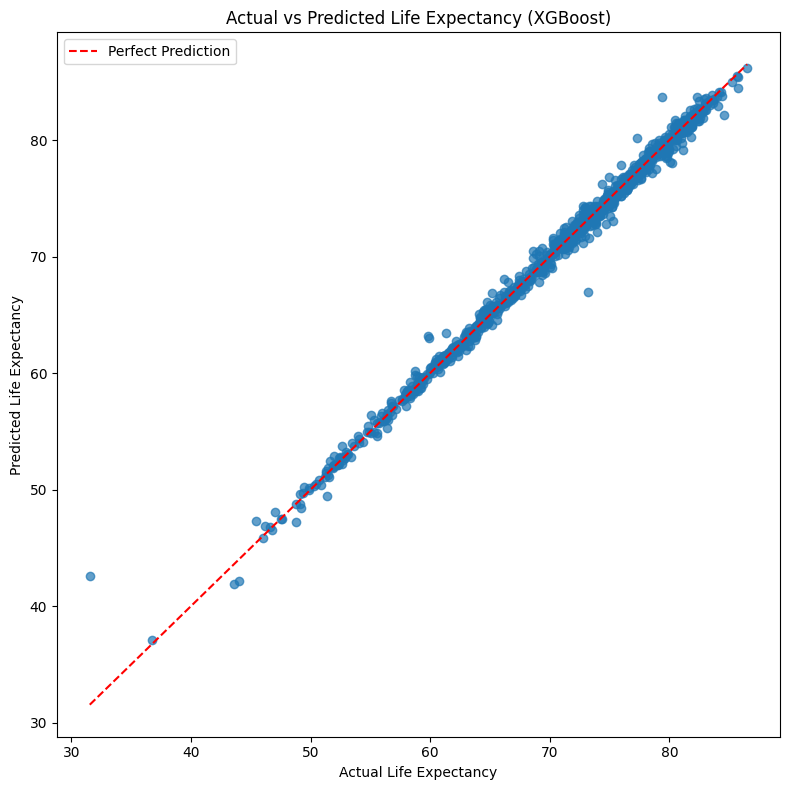

In [ ]:
# Generate predictions using the trained XGBoost model
y_pred_xgb = xgb_model.predict(X_test_final_num)

# Plot actual versus predicted life expectancy values
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

# Add a reference line representing perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Prediction"
)

plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy (XGBoost)")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows that the predicted life expectancy values closely follow the diagonal reference line, indicating strong agreement between the model predictions and the actual observations.

Most prediction errors are relatively small, with only a few observations deviating noticeably from the reference line. This suggests that the XGBoost model is able to accurately capture the relationship between the predictor variables and life expectancy while maintaining good generalization on unseen data.

## Residual Analysis

Residual analysis evaluates the prediction errors of the final model.

Residuals are calculated as:

**Residual = Actual Value − Predicted Value**

An effective regression model should produce residuals that are centered around zero without obvious patterns, indicating that prediction errors are random rather than systematic.

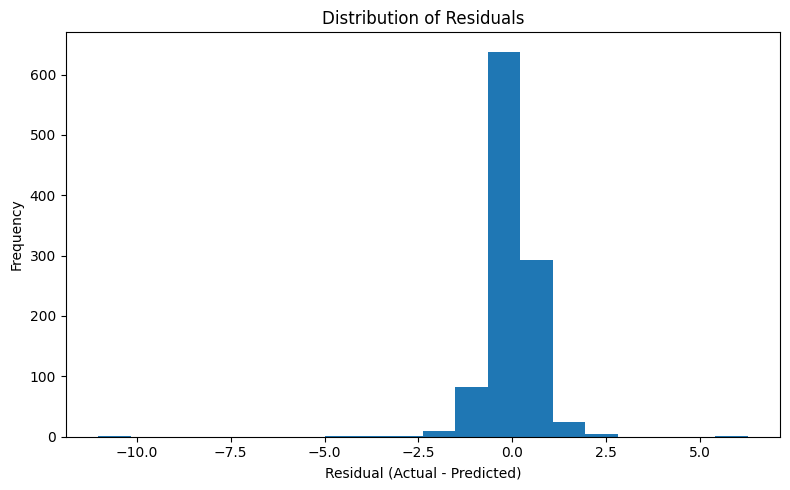

In [ ]:
# Calculate prediction residuals
residuals = y_test - y_pred_xgb

# Plot the distribution of residuals
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=20)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Interpretation

The residual distribution is approximately centered around zero, indicating that the model does not consistently overestimate or underestimate life expectancy.

Most residuals are concentrated close to zero, while only a small number of larger errors are observed. This suggests that the XGBoost model provides accurate predictions for the majority of observations.

### Residuals vs Predicted Values

A residual plot is used to determine whether the prediction errors are randomly distributed across the range of predicted life expectancy values.

A random scatter around the zero reference line indicates that the model has captured the underlying relationships without introducing systematic bias.

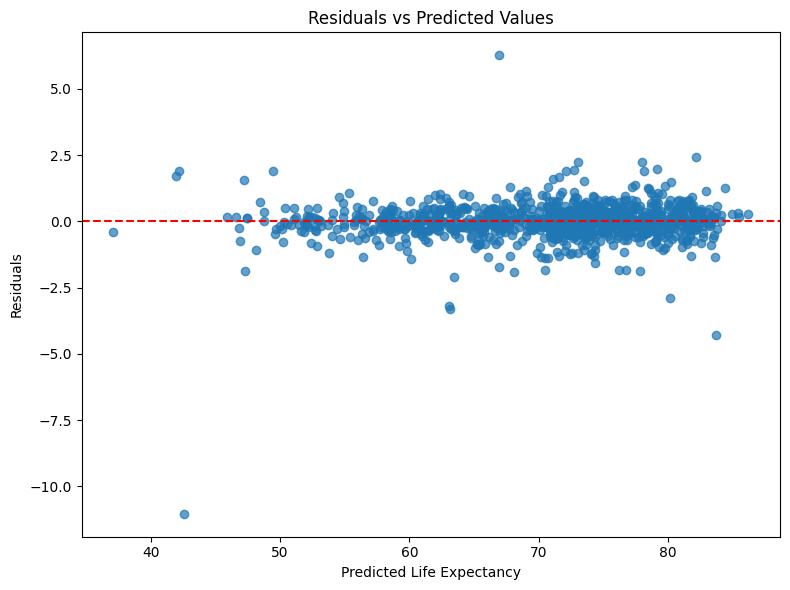

In [ ]:
# Plot residuals against predicted values
plt.figure(figsize=(8,6))

plt.scatter(y_pred_xgb, residuals, alpha=0.7)

# Add a horizontal reference line at zero residual
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.tight_layout()
plt.show()

### Interpretation

The residuals are randomly scattered around the zero reference line, with no obvious trend or systematic pattern.

Although a few outliers are present, the overall spread of the residuals remains relatively consistent across the predicted values. This indicates that the XGBoost model does not exhibit significant bias and generalizes well to unseen data.

## Model Evaluation Summary

The evaluation of the selected XGBoost model demonstrates strong predictive performance.

- Feature importance analysis identified mortality, maternal health, and economic indicators as the most influential predictors.
- The Actual vs Predicted plot showed a close agreement between predicted and observed life expectancy values.
- Residual analysis indicated that prediction errors are centered around zero and are randomly distributed, suggesting that the model does not exhibit significant systematic bias.

Overall, these findings support the selection of XGBoost as the final model for life expectancy prediction.

#7. Discussion

This project developed and evaluated five machine learning regression models to predict life expectancy using national health, demographic, and socioeconomic indicators from the WHO Health Indicators dataset. Following data preprocessing, exploratory data analysis, feature engineering, and model development, the performance of Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost was compared.

Among the evaluated models, **XGBoost** achieved the best overall predictive performance, with an **R² score of 0.9936**, a **Mean Absolute Error (MAE) of 0.4230**, and a **Root Mean Squared Error (RMSE) of 0.7012**. These results indicate that the model explains approximately **99.36%** of the variation in life expectancy while maintaining very low prediction errors.

Feature importance analysis showed that **under-five mortality** was the most influential predictor, followed by **maternal mortality**, **GDP per capita**, **death rate**, and **sanitation coverage**. The engineered **Disease Burden Ratio** also contributed to the model, demonstrating that the feature engineering process added meaningful predictive information. Overall, these findings are consistent with established public health knowledge, where child survival, maternal health, economic development, and access to basic healthcare services are recognized as major determinants of life expectancy.

The model evaluation plots further confirmed the quality of the selected model. The Actual vs Predicted plot showed that most predictions closely followed the ideal prediction line, indicating strong agreement between predicted and observed life expectancy values. Similarly, the residual analysis showed that prediction errors were centered around zero and randomly distributed, suggesting that the model does not exhibit significant systematic bias and generalizes well to unseen data.

During model development, the initial evaluation produced unusually high performance, prompting an investigation into potential target leakage. The variables **life_expectancy_male** and **life_expectancy_female** were identified as leakage features because they were directly related to the target variable. After removing these variables and retraining the models, the final evaluation produced more reliable and realistic results.

Although the model achieved excellent predictive performance, several limitations should be acknowledged. The analysis relied on historical country-level indicators and therefore may not capture all factors influencing life expectancy, such as genetic, environmental, political, or cultural influences. In addition, while the model identifies strong predictive relationships, it should not be interpreted as establishing causal relationships between the predictor variables and life expectancy.

#8. Conclusion

This project successfully developed and evaluated a machine learning model capable of accurately predicting life expectancy using national health, demographic, and socioeconomic indicators. After comparing five regression algorithms, **XGBoost** was selected as the final model because it achieved the highest predictive accuracy, the lowest prediction errors, and the best overall generalization performance.

The analysis demonstrated that **under-five mortality**, **maternal mortality**, **GDP per capita**, **death rate**, and **sanitation coverage** are among the most influential factors associated with life expectancy. These findings are consistent with existing public health knowledge and reinforce the importance of investments in healthcare systems, maternal and child health services, sanitation, and economic development to improve population health outcomes.

This project also highlights the importance of following a complete and reliable machine learning workflow. Careful data preprocessing, exploratory data analysis, feature engineering, model comparison, and the investigation of target leakage all contributed to the development of a robust predictive model.

Overall, the results demonstrate the potential of machine learning to support public health analytics and evidence-based decision-making. Models such as XGBoost can assist policymakers, healthcare organizations, and researchers in identifying the key factors associated with life expectancy and supporting informed planning and resource allocation.

Future work could include hyperparameter optimization, cross-validation, external validation using independent datasets, the incorporation of additional health indicators, and the application of explainable AI techniques such as SHAP values to further improve model interpretability.